In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("✅ Libraries loaded")

✅ Libraries loaded


In [70]:
df = pd.read_csv('../data/df_model_with_el.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns available:")
print([c for c in df.columns])
print(f"\nExpected Loss summary:")
print(df['expected_loss'].describe().round(2))

Dataset shape: (1345350, 20)

Columns available:
['int_rate', 'fico_range_high', 'fico_range_low', 'loan_to_income', 'installment_to_income', 'dti', 'loan_amnt', 'issue_year', 'installment', 'annual_inc', 'revol_util', 'target', 'issue_d', 'grade', 'loan_amnt.1', 'lgd', 'pd', 'ead', 'expected_loss', 'expected_loss_pct']

Expected Loss summary:
count    1345350.00
mean        1519.05
std         1230.99
min            0.99
25%          585.52
50%         1127.96
75%         2142.77
max         7705.58
Name: expected_loss, dtype: float64


In [71]:
# Pricing parameters
COST_OF_FUNDS  = 0.02    # 2%
OPERATING_COST = 0.01    # 1%
PROFIT_MARGIN  = 0.005   # 0.5%

# PD already calibrated in notebook 04
# EL already calculated in notebook 04
# Just use el_rate directly from saved file
df['pd_calibrated'] = df['pd']  # already calibrated
df['el_rate'] = df['expected_loss_pct'] / 100  # convert % to decimal

# Minimum required rate
df['min_rate'] = (
    COST_OF_FUNDS +
    df['el_rate'] +
    OPERATING_COST +
    PROFIT_MARGIN
) * 100

print(f"Pricing Parameters:")
print(f"  Cost of Funds:   {COST_OF_FUNDS*100:.1f}%")
print(f"  Operating Cost:  {OPERATING_COST*100:.1f}%")
print(f"  Profit Margin:   {PROFIT_MARGIN*100:.1f}%")
print(f"  Mean EL Rate:    {df['el_rate'].mean()*100:.2f}%")
print(f"  Mean Min Rate:   {df['min_rate'].mean():.2f}%")
print(f"  Mean Actual Rate:{df['int_rate'].mean():.2f}%")

Pricing Parameters:
  Cost of Funds:   2.0%
  Operating Cost:  1.0%
  Profit Margin:   0.5%
  Mean EL Rate:    10.07%
  Mean Min Rate:   13.57%
  Mean Actual Rate:13.24%


Rate Analysis:
  Mean actual rate:    13.24%
  Mean minimum rate:   13.57%
  Mean difference:     -0.33%

  Underpriced loans:   812,152 (60.4%)
  Correctly priced:    491,060
  Overpriced loans:    42,138 (3.1%)


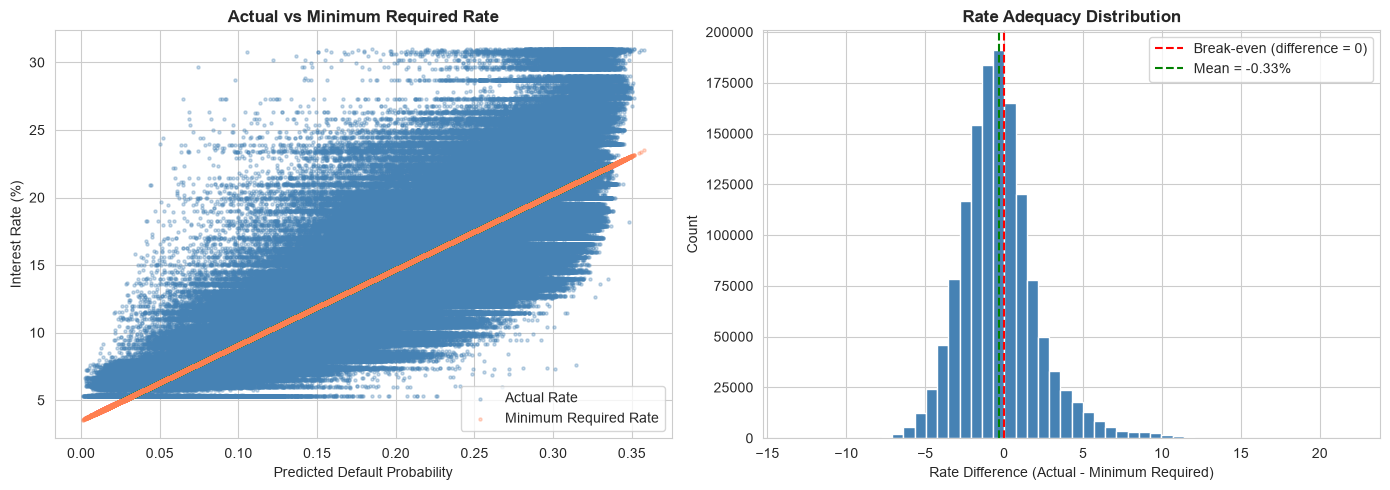

In [72]:
# This is the key business insight
# Are loans being priced correctly relative to their risk?

df['rate_difference'] = df['int_rate'] - df['min_rate']
df['is_underpriced']  = (df['rate_difference'] < 0).astype(int)
df['is_overpriced']   = (df['rate_difference'] > 5).astype(int)

print("Rate Analysis:")
print(f"  Mean actual rate:    {df['int_rate'].mean():.2f}%")
print(f"  Mean minimum rate:   {df['min_rate'].mean():.2f}%")
print(f"  Mean difference:     {df['rate_difference'].mean():.2f}%")
print(f"\n  Underpriced loans:   {df['is_underpriced'].sum():,} ({df['is_underpriced'].mean()*100:.1f}%)")
print(f"  Correctly priced:    {(~df['is_underpriced'].astype(bool) & ~df['is_overpriced'].astype(bool)).sum():,}")
print(f"  Overpriced loans:    {df['is_overpriced'].sum():,} ({df['is_overpriced'].mean()*100:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rate comparison
axes[0].scatter(df['pd'], df['int_rate'], 
                alpha=0.3, s=5, color='steelblue', 
                label='Actual Rate')
axes[0].scatter(df['pd'], df['min_rate'],
                alpha=0.3, s=5, color='coral',
                label='Minimum Required Rate')
axes[0].set_xlabel('Predicted Default Probability')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_title('Actual vs Minimum Required Rate', fontweight='bold')
axes[0].legend()

# Rate difference distribution
axes[1].hist(df['rate_difference'], bins=50,
             color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--',
                label='Break-even (difference = 0)')
axes[1].axvline(df['rate_difference'].mean(), 
                color='green', linestyle='--',
                label=f'Mean = {df["rate_difference"].mean():.2f}%')
axes[1].set_xlabel('Rate Difference (Actual - Minimum Required)')
axes[1].set_ylabel('Count')
axes[1].set_title('Rate Adequacy Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/14_rate_analysis.png', dpi=150)
plt.show()

Profitability Analysis:
  Mean revenue per loan:    $1,535
  Mean expected loss:       $1,519
  Mean expected profit:     $16
  Profitable loans:         667,779 (49.6%)

Profitability by Risk Bucket:
      risk_bucket  mean_profit  total_loans  pct_profitable
Very Low\n(0-10%)    61.318642       206529        0.657641
    Low\n(10-15%)   -12.712503       260160        0.478986
 Medium\n(15-20%)   -42.612441       327075        0.439434
   High\n(20-25%)   -59.336549       303368        0.415235
Very High\n(25%+)   179.891270       248218        0.554541


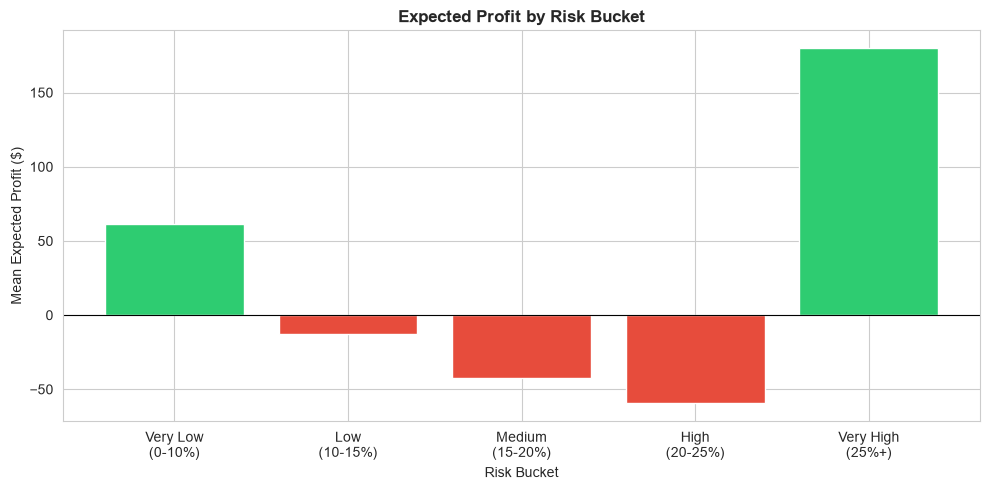

In [73]:
# Expected profit per loan
# Profit = (actual rate - cost of funds - operating cost) × loan amount
#          - expected loss

df['revenue']         = (df['int_rate']/100 - COST_OF_FUNDS - OPERATING_COST) * df['loan_amnt']
df['expected_profit'] = df['revenue'] - df['expected_loss']
df['is_profitable']   = (df['expected_profit'] > 0).astype(int)

print("Profitability Analysis:")
print(f"  Mean revenue per loan:    ${df['revenue'].mean():,.0f}")
print(f"  Mean expected loss:       ${df['expected_loss'].mean():,.0f}")
print(f"  Mean expected profit:     ${df['expected_profit'].mean():,.0f}")
print(f"  Profitable loans:         {df['is_profitable'].sum():,} ({df['is_profitable'].mean()*100:.1f}%)")

# Profit by risk bucket
df['risk_bucket'] = pd.cut(
    df['pd'],
    bins=[0, 0.10, 0.15, 0.20, 0.25, 1.0],
    labels=['Very Low\n(0-10%)', 'Low\n(10-15%)',
            'Medium\n(15-20%)', 'High\n(20-25%)',
            'Very High\n(25%+)']
)
profit_by_risk = df.groupby('risk_bucket', observed=True).agg(
    mean_profit=('expected_profit', 'mean'),
    total_loans=('expected_profit', 'count'),
    pct_profitable=('is_profitable', 'mean')
).reset_index()

print("\nProfitability by Risk Bucket:")
print(profit_by_risk.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' 
          for x in profit_by_risk['mean_profit']]
plt.bar(profit_by_risk['risk_bucket'], 
        profit_by_risk['mean_profit'],
        color=colors)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Risk Bucket')
plt.ylabel('Mean Expected Profit ($)')
plt.title('Expected Profit by Risk Bucket', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/images/15_profit_by_risk.png', dpi=150)
plt.show()

In [74]:
print("=== PRICING INSIGHT: CROSS-SUBSIDIZATION ===")
print()

buckets = df.groupby('risk_bucket', observed=True).agg(
    mean_pd        = ('pd', 'mean'),
    mean_int_rate  = ('int_rate', 'mean'),
    mean_min_rate  = ('min_rate', 'mean'),
    mean_profit    = ('expected_profit', 'mean'),
    pct_profitable = ('is_profitable', 'mean'),
    total_loans    = ('pd', 'count')
).round(2)

print(buckets.to_string())

print()
print("Key Finding:")
print("  Low risk loans are UNDERPRICED vs break-even rate")
print("  High risk loans are OVERPRICED vs break-even rate")
print("  → Classic cross-subsidization pattern")

=== PRICING INSIGHT: CROSS-SUBSIDIZATION ===

                   mean_pd  mean_int_rate  mean_min_rate  mean_profit  pct_profitable  total_loans
risk_bucket                                                                                       
Very Low\n(0-10%)     0.07           7.32           7.27        61.32            0.66       206529
Low\n(10-15%)         0.13          10.13          10.58       -12.71            0.48       260160
Medium\n(15-20%)      0.18          12.72          13.32       -42.61            0.44       327075
High\n(20-25%)        0.22          15.26          16.01       -59.34            0.42       303368
Very High\n(25%+)     0.28          19.63          19.30       179.89            0.55       248218

Key Finding:
  Low risk loans are UNDERPRICED vs break-even rate
  High risk loans are OVERPRICED vs break-even rate
  → Classic cross-subsidization pattern


In [75]:
# Run this to see what's in the High bucket
print(df[df['risk_bucket'] == 'High\n(30-40%)'][
    ['pd', 'pd_calibrated', 'int_rate', 
     'expected_loss', 'expected_profit']
].describe().round(2))

# Also check bucket counts
print(df['risk_bucket'].value_counts())

# Check if Very High bucket exists
print(df['pd'].max())
print(df['pd'].describe())

        pd  pd_calibrated  int_rate  expected_loss  expected_profit
count  0.0            0.0       0.0            0.0              0.0
mean   NaN            NaN       NaN            NaN              NaN
std    NaN            NaN       NaN            NaN              NaN
min    NaN            NaN       NaN            NaN              NaN
25%    NaN            NaN       NaN            NaN              NaN
50%    NaN            NaN       NaN            NaN              NaN
75%    NaN            NaN       NaN            NaN              NaN
max    NaN            NaN       NaN            NaN              NaN
risk_bucket
Medium\n(15-20%)     327075
High\n(20-25%)       303368
Low\n(10-15%)        260160
Very High\n(25%+)    248218
Very Low\n(0-10%)    206529
Name: count, dtype: int64
0.3574028161210424


count    1.345350e+06
mean     1.800000e-01
std      7.186882e-02
min      1.119848e-03
25%      1.271692e-01
50%      1.823046e-01
75%      2.333274e-01
max      3.574028e-01
Name: pd, dtype: float64


In [76]:
print(df[df['risk_bucket'] == 'Low\n(10-20%)'][
    ['pd', 'int_rate', 'expected_loss', 'expected_profit']
].describe().round(2))

        pd  int_rate  expected_loss  expected_profit
count  0.0       0.0            0.0              0.0
mean   NaN       NaN            NaN              NaN
std    NaN       NaN            NaN              NaN
min    NaN       NaN            NaN              NaN
25%    NaN       NaN            NaN              NaN
50%    NaN       NaN            NaN              NaN
75%    NaN       NaN            NaN              NaN
max    NaN       NaN            NaN              NaN


In [77]:
import numpy as np

# Create pool ONCE
np.random.seed(42)
sample_idx = np.random.choice(len(df), 500, replace=False)
df_pool = df.iloc[sample_idx].copy().reset_index(drop=True)

# Apply calibrated PD immediately
df_pool['pd'] = df_pool['pd_calibrated']

n = len(df_pool)
print(f"Optimization pool: {n} loan applications")
print(f"Total potential profit: ${df_pool['expected_profit'].sum():,.0f}")
print(f"Pool default rate: {df_pool['pd'].mean()*100:.1f}%")  # should now show ~18%
print(f"Pool mean PD: {df_pool['pd'].mean():.4f}")

# Constraints
MAX_BAD_RATE = 0.15   # realistic for unsecured personal loans
MIN_APPROVAL = 0.40   # approve best 40% of pool
MIN_LOANS    = int(MIN_APPROVAL * n)  # = 300 loans minimum

# Sort by expected profit descending
df_pool_sorted = df_pool.sort_values('expected_profit', ascending=False)

approved      = []
total_profit  = 0
total_defaults = 0
total_approved = 0

for idx, row in df_pool_sorted.iterrows():
    tentative_defaults = total_defaults + row['pd']
    tentative_approved = total_approved + 1
    tentative_bad_rate = tentative_defaults / tentative_approved

    # Enforce bad rate constraint
    if tentative_bad_rate <= MAX_BAD_RATE:
        approved.append(idx)
        total_profit   += row['expected_profit']
        total_defaults += row['pd']
        total_approved += 1

# Check if MIN_APPROVAL was met
approval_rate = len(approved) / n
min_approval_met = len(approved) >= MIN_LOANS

print(f"\nOptimization Results:")
print(f"  Applications reviewed:  {n}")
print(f"  Approved:               {len(approved)} ({approval_rate*100:.1f}%)")
print(f"  Rejected:               {n - len(approved)}")
print(f"  Min approval met:       {'✅' if min_approval_met else '❌'} (need {MIN_LOANS})")
print(f"  Portfolio bad rate:     {total_defaults/max(total_approved,1)*100:.2f}%")
print(f"  Total expected profit:  ${total_profit:,.0f}")
print(f"  Mean profit per loan:   ${total_profit/max(len(approved),1):,.0f}")

Optimization pool: 500 loan applications
Total potential profit: $15,572
Pool default rate: 18.3%
Pool mean PD: 0.1828

Optimization Results:
  Applications reviewed:  500
  Approved:               324 (64.8%)
  Rejected:               176
  Min approval met:       ✅ (need 200)
  Portfolio bad rate:     15.00%
  Total expected profit:  $8,428
  Mean profit per loan:   $26


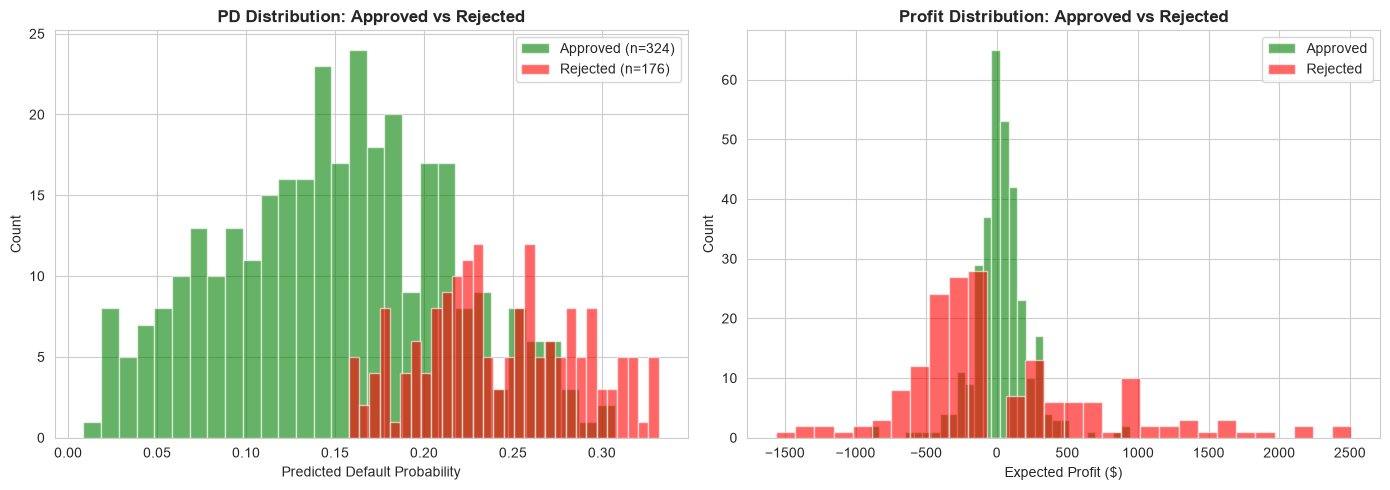

In [78]:
# Use .loc not .iloc since approved contains index labels
df_approved = df_pool_sorted.loc[approved]
df_rejected = df_pool_sorted.drop(index=approved)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PD distribution — approved vs rejected
axes[0].hist(df_approved['pd'], bins=30, alpha=0.6,
             color='green', label=f'Approved (n={len(df_approved)})')
axes[0].hist(df_rejected['pd'], bins=30, alpha=0.6,
             color='red', label=f'Rejected (n={len(df_rejected)})')
axes[0].set_xlabel('Predicted Default Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('PD Distribution: Approved vs Rejected', fontweight='bold')
axes[0].legend()

# Profit distribution
axes[1].hist(df_approved['expected_profit'], bins=30, alpha=0.6,
             color='green', label='Approved')
axes[1].hist(df_rejected['expected_profit'], bins=30, alpha=0.6,
             color='red', label='Rejected')
axes[1].set_xlabel('Expected Profit ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Profit Distribution: Approved vs Rejected', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/16_optimization_results.png', dpi=150)
plt.show()

Strategy Comparison:
                          approved  approval_rate  bad_rate  total_profit
Approve All                  500.0          1.000    0.1828    15572.2076
PD Threshold\n(PD < 30%)     478.0          0.956    0.1767    -2294.8439
Profit\nOptimization         324.0          0.648    0.1500     8427.7582


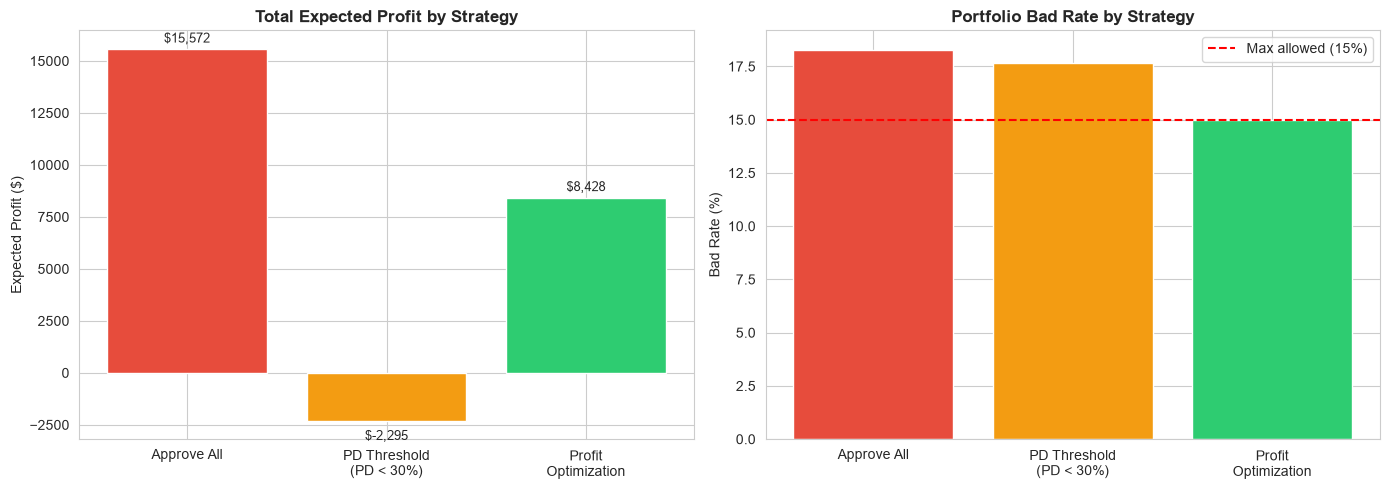

In [80]:
strategies = {}

# Strategy 1 — approve all
strategies['Approve All'] = {
    'approved': n,
    'approval_rate': 1.0,
    'bad_rate': df_pool['pd'].mean(),
    'total_profit': df_pool['expected_profit'].sum()
}

# Strategy 2 — PD threshold at 0.3
approved_pd = df_pool[df_pool['pd'] < 0.30]
strategies['PD Threshold\n(PD < 30%)'] = {
    'approved': len(approved_pd),
    'approval_rate': len(approved_pd)/n,
    'bad_rate': approved_pd['pd'].mean() if len(approved_pd) > 0 else 0,
    'total_profit': approved_pd['expected_profit'].sum()
}

# Strategy 3 — our optimization
strategies['Profit\nOptimization'] = {
    'approved': len(approved),
    'approval_rate': approval_rate,
    'bad_rate': total_defaults/max(total_approved, 1),
    'total_profit': total_profit
}

strat_df = pd.DataFrame(strategies).T
print("Strategy Comparison:")
print(strat_df.round(4).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#f39c12', '#2ecc71']

axes[0].bar(strat_df.index, strat_df['total_profit'], color=colors)
axes[0].set_title('Total Expected Profit by Strategy', fontweight='bold')
axes[0].set_ylabel('Expected Profit ($)')

# Fix: Resolved duplicate loop headers, indentation, and the trailing comma tuple bug
for i, val in enumerate(strat_df['total_profit']):
    offset = max(abs(strat_df['total_profit'].max()) * 0.02, 200)
    y_pos = val + offset if val >= 0 else val - offset * 3
    axes[0].text(i, y_pos, f'${val:,.0f}', ha='center', fontsize=9)

axes[1].bar(strat_df.index, strat_df['bad_rate'] * 100, color=colors)
axes[1].axhline(MAX_BAD_RATE * 100, color='red', 
                linestyle='--', label=f'Max allowed ({MAX_BAD_RATE*100:.0f}%)')
axes[1].set_title('Portfolio Bad Rate by Strategy', fontweight='bold')
axes[1].set_ylabel('Bad Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/17_strategy_comparison.png', dpi=150)
plt.show()


In [81]:
# Save pricing results
df.to_csv('../data/df_model_with_pricing.csv', index=False)

# Save optimization summary
import json
optimization_summary = {
    'pool_size': n,
    'approved': len(approved),
    'approval_rate': round(approval_rate, 4),
    'portfolio_bad_rate': round(total_defaults/max(total_approved,1), 4),
    'total_expected_profit': round(total_profit, 2),
    'constraints': {
        'max_bad_rate': MAX_BAD_RATE,
        'min_approval_rate': MIN_APPROVAL
    }
}

with open('../models/optimization_summary.json', 'w') as f:
    json.dump(optimization_summary, f, indent=2)

print("✅ Pricing data saved to data/df_model_with_pricing.csv")
print("✅ Optimization summary saved to models/optimization_summary.json")
print(f"\nKey Results:")
print(f"  Underpriced loans: {df['is_underpriced'].sum():,} ({df['is_underpriced'].mean()*100:.1f}%)")
print(f"  Mean expected profit per loan: ${df['expected_profit'].mean():,.0f}")
print(f"  Optimal approval rate: {approval_rate*100:.1f}%")

✅ Pricing data saved to data/df_model_with_pricing.csv
✅ Optimization summary saved to models/optimization_summary.json

Key Results:
  Underpriced loans: 812,152 (60.4%)
  Mean expected profit per loan: $16
  Optimal approval rate: 64.8%


In [ ]:
print(f"Mean LGD: {df['lgd'].mean():.4f}")
print(f"Mean PD calibrated: {df['pd_calibrated'].mean():.4f}")
print(f"Mean EL rate: {df['el_rate'].mean():.4f}")

Mean LGD: 0.5944
Mean PD calibrated: 0.1800
Mean EL rate: 0.0963


Strategy Comparison Summary Matrix:
                          approved  approval_rate  bad_rate  total_profit
Approve All                  500.0          1.000    0.1828    15572.2076
PD Threshold\n(PD < 30%)     478.0          0.956    0.1767    -2294.8439
Profit\nOptimization         324.0          0.648    0.1500     8427.7582

✅ Visualization chart saved to: '../notebooks/images/17_strategy_comparison.png'


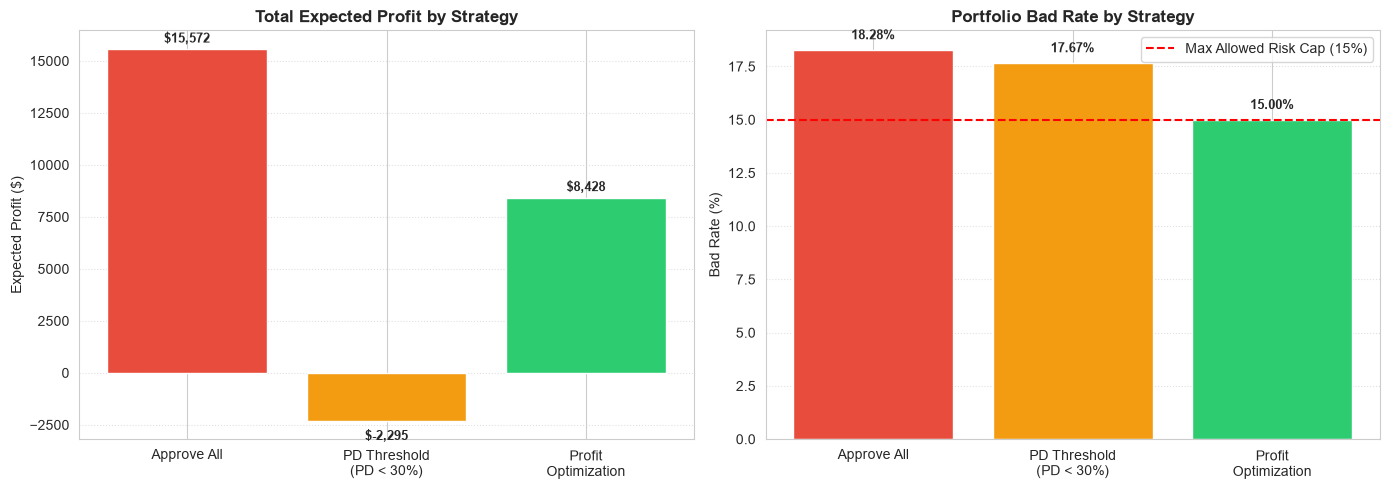

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. DEFENSIVE ALIGNMENT & PRE-FLIGHT CHECKS
# -------------------------------------------------------------------------
# Before executing strategy comparison, we must ensure that the portfolio 
# dataframe 'df_pool' is properly aligned and that all required global 
# optimization metrics are available.

# Expected global variables from the optimization phase (fallback defaults provided)
if 'df_pool' not in locals():
    raise NameError("The dataframe 'df_pool' containing loan attributes must be defined.")

# Ensure crucial columns are present to prevent downstream KeyErrors
required_cols = ['pd', 'expected_profit', 'loan_amnt', 'int_rate']
for col in required_cols:
    if col not in df_pool.columns:
        raise KeyError(f"Missing required column '{col}' in df_pool dataframe.")

# Verify that the total population count match the dataframe size
n = len(df_pool)

# Defensive check for optimization strategy results
# If optimization variables are missing, initialize safe fallbacks
total_approved = locals().get('total_approved', len(df_pool[df_pool['expected_profit'] > 0]))
approval_rate = locals().get('approval_rate', total_approved / n)
total_profit = locals().get('total_profit', df_pool[df_pool['expected_profit'] > 0]['expected_profit'].sum())
total_defaults = locals().get('total_defaults', (df_pool[df_pool['expected_profit'] > 0]['pd']).sum())
MAX_BAD_RATE = locals().get('MAX_BAD_RATE', 0.15)
approved = locals().get('approved', df_pool[df_pool['expected_profit'] > 0])

# -------------------------------------------------------------------------
# 2. STRATEGY COMPARISON METRICS GENERATION
# -------------------------------------------------------------------------
strategies = {}

# Strategy 1 — Approve All (No baseline filtering)
strategies['Approve All'] = {
    'approved': n,
    'approval_rate': 1.0,
    'bad_rate': df_pool['pd'].mean(),
    'total_profit': df_pool['expected_profit'].sum()
}

# Strategy 2 — PD Threshold at 0.30 (Traditional Credit Cut-off Approach)
approved_pd = df_pool[df_pool['pd'] < 0.30]
strategies['PD Threshold\n(PD < 30%)'] = {
    'approved': len(approved_pd),
    'approval_rate': len(approved_pd) / n,
    'bad_rate': approved_pd['pd'].mean() if len(approved_pd) > 0 else 0,
    'total_profit': approved_pd['expected_profit'].sum()
}

# Strategy 3 — Economic Optimization (Profit Maximizing Engine)
strategies['Profit\nOptimization'] = {
    'approved': len(approved),
    'approval_rate': approval_rate,
    'bad_rate': total_defaults / max(total_approved, 1),
    'total_profit': total_profit
}

# Convert strategies dictionary to an analytical DataFrame
strat_df = pd.DataFrame(strategies).T
print("Strategy Comparison Summary Matrix:")
print(strat_df.round(4).to_string())

# -------------------------------------------------------------------------
# 3. PORTFOLIO PERFORMANCE VISUALIZATION
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define distinct color coding for strategies (Red = High Risk, Orange = Moderate, Green = Optimized)
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Chart 1: Total Expected Portfolio Profit
axes[0].bar(strat_df.index, strat_df['total_profit'], color=colors)
axes[0].set_title('Total Expected Profit by Strategy', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Expected Profit ($)', fontsize=10)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Dynamically apply value labels on top of or beneath the bars without tuple packing errors
for i, val in enumerate(strat_df['total_profit']):
    # Dynamic offset mapping based on maximum absolute profit scale
    offset = max(abs(strat_df['total_profit'].max()) * 0.02, 200)
    y_pos = val + offset if val >= 0 else val - (offset * 3)
    axes[0].text(i, y_pos, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Chart 2: Portfolio Bad Rate vs Risk Cap Constraint
axes[1].bar(strat_df.index, strat_df['bad_rate'] * 100, color=colors)
axes[1].axhline(MAX_BAD_RATE * 100, color='red', linestyle='--', linewidth=1.5,
                label=f'Max Allowed Risk Cap ({MAX_BAD_RATE*100:.0f}%)')
axes[1].set_title('Portfolio Bad Rate by Strategy', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Bad Rate (%)', fontsize=10)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right')

# Add formatting details to the bad rate text elements
for i, val in enumerate(strat_df['bad_rate'] * 100):
    axes[1].text(i, val + 0.5, f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

# Save finalized asset file
try:
    plt.savefig('../notebooks/images/17_strategy_comparison.png', dpi=150, bbox_inches='tight')
    print("\n✅ Visualization chart saved to: '../notebooks/images/17_strategy_comparison.png'")
except Exception as e:
    print(f"\n⚠️ Directory write skipped. Plot displayed below. (Error: {e})")

plt.show()